In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# consistent style for all visualizations
sns.set_style("whitegrid")

# Load the dataset

df = pd.read_csv('US_Customer_Insights_Dataset.csv')

print("Data loaded successfully. Ready for Step 1.")


Data loaded successfully. Ready for Step 1.


In [2]:
# 1. Preview the first 5 rows
print("--- Data Preview (Head) ---")
print(df.head().to_markdown(index=False, numalign="left", stralign="left"))

# 2. Check data types and nulls
print("\n--- Data Structure (Info) ---")
df.info()

# 3. Check unique values for key categorical columns
print("\n--- Value Counts for Key Categorical Columns ---")
print("Education:\n", df['Education'].value_counts().to_markdown())
print("Gender:\n", df['Gender'].value_counts().to_markdown())

--- Data Preview (Head) ---
| CustomerID   | Name             | State      | Education   | Gender     | Age   | Married   | NumPets   | JoinDate   | TransactionDate   | MonthlySpend   | DaysSinceLastInteraction   |
|:-------------|:-----------------|:-----------|:------------|:-----------|:------|:----------|:----------|:-----------|:------------------|:---------------|:---------------------------|
| CUST10319    | Scott Perez      | Florida    | High School | Non-Binary | 47    | Yes       | 1         | 9/19/21    | 9/2/24            | 1281.74        | 332                        |
| CUST10695    | Jennifer Burton  | Washington | Master      | Male       | 72    | Yes       | 0         | 4/5/24     | 6/2/24            | 429.46         | 424                        |
| CUST10297    | Michelle Rogers  | Arizona    | Master      | Female     | 40    | Yes       | 2         | 7/24/24    | 2/28/25           | 510.34         | 153                        |
| CUST10103    | Brooke Hendricks | T

In [3]:
# Step 2: Descriptive Statistics
# numerical statistics
numerical_cols = ['Age', 'MonthlySpend', 'DaysSinceLastInteraction', 'NumPets']
numerical_stats = df[numerical_cols].describe().T

print("--- Descriptive Statistics ---")
print(numerical_stats[['mean', '50%', 'std', 'min', 'max']].to_markdown(floatfmt=".2f"))

--- Descriptive Statistics ---
|                          |   mean |    50% |    std |   min |     max |
|:-------------------------|-------:|-------:|-------:|------:|--------:|
| Age                      |  49.47 |  49.00 |  18.22 | 18.00 |   80.00 |
| MonthlySpend             | 331.61 | 282.11 | 225.80 |  3.89 | 1740.42 |
| DaysSinceLastInteraction | 538.47 | 445.00 | 398.77 |  1.00 | 1791.00 |
| NumPets                  |   1.34 |   1.00 |   1.15 |  0.00 |    4.00 |


In [4]:
# categorical statistics
categorical_cols = ['Gender', 'Education', 'Married']
print("\n--- Mode for Categorical Variables ---")

for col in categorical_cols:
    mode_value = df[col].mode()[0]
    print(f"Mode of {col}: {mode_value}")



--- Mode for Categorical Variables ---
Mode of Gender: Male
Mode of Education: Master
Mode of Married: No


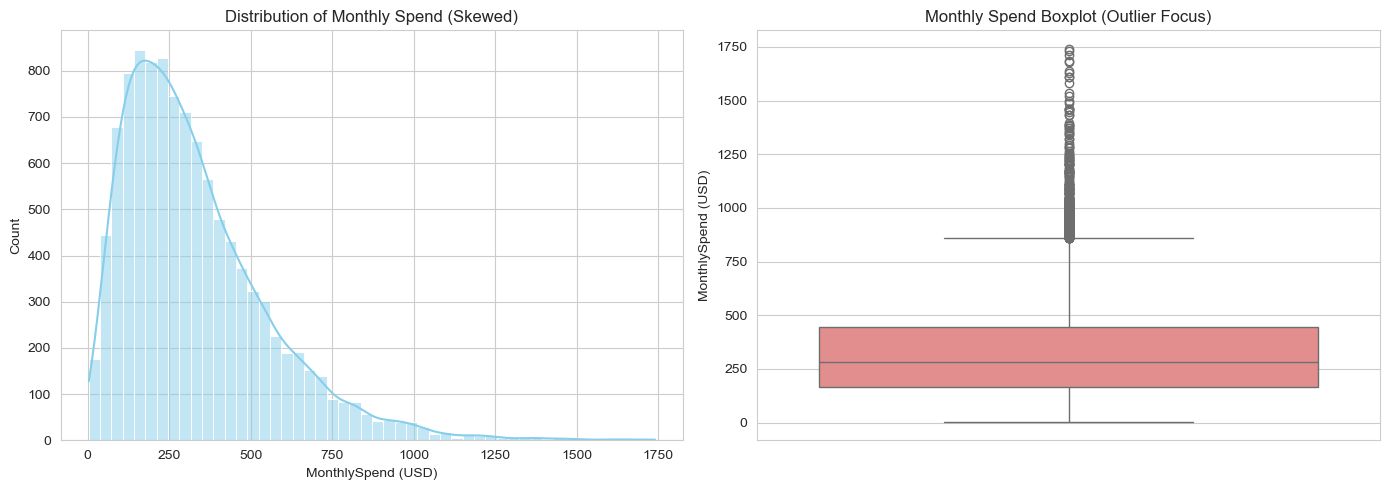

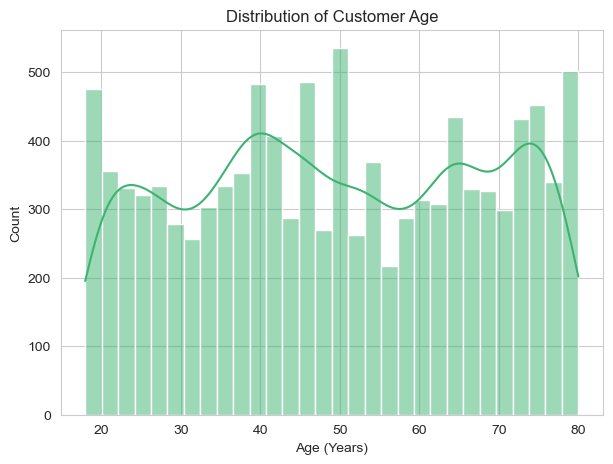

In [5]:
# Step 3: Data Visualization
# MonthlySpend Distribution (Skew Check)
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['MonthlySpend'], kde=True, bins=50, color='skyblue')
plt.title('Distribution of Monthly Spend (Skewed)')
plt.xlabel('MonthlySpend (USD)')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['MonthlySpend'], color='lightcoral')
plt.title('Monthly Spend Boxplot (Outlier Focus)')
plt.ylabel('MonthlySpend (USD)')
plt.tight_layout()
plt.show()

# Age Distribution
plt.figure(figsize=(7, 5))
sns.histplot(df['Age'], kde=True, bins=30, color='mediumseagreen')
plt.title('Distribution of Customer Age')
plt.xlabel('Age (Years)')
plt.show()

C:\Users\disha\AppData\Local\Temp\ipykernel_22832\266217656.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Education')


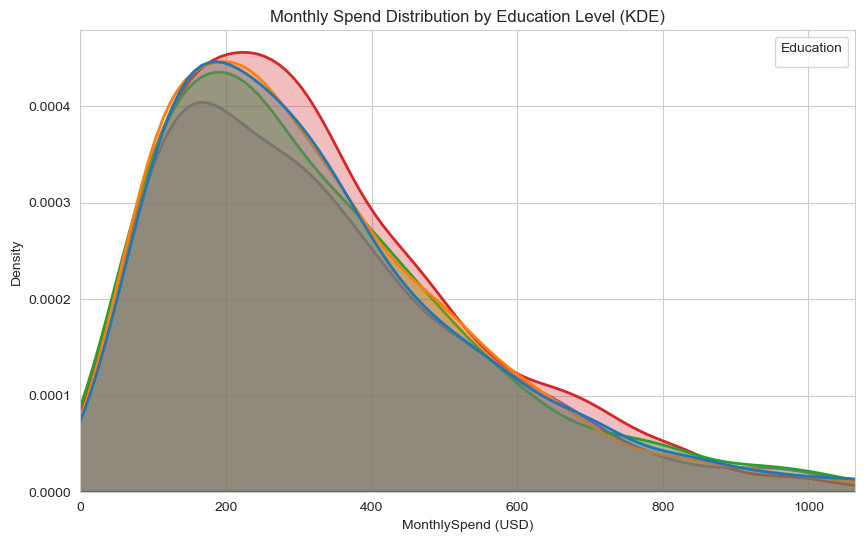

In [6]:
# KDE: Spending behavior by education level
plt.figure(figsize=(10, 6))
education_order = ['High School', 'Associate', 'Bachelor', 'Master', 'PhD']
sns.kdeplot(data=df, x='MonthlySpend', hue='Education', hue_order=education_order,
            fill=True, alpha=.3, linewidth=2)
plt.title('Monthly Spend Distribution by Education Level (KDE)')
plt.xlabel('MonthlySpend (USD)')
plt.xlim(0, df['MonthlySpend'].quantile(0.99)) 
plt.legend(title='Education')
plt.show()

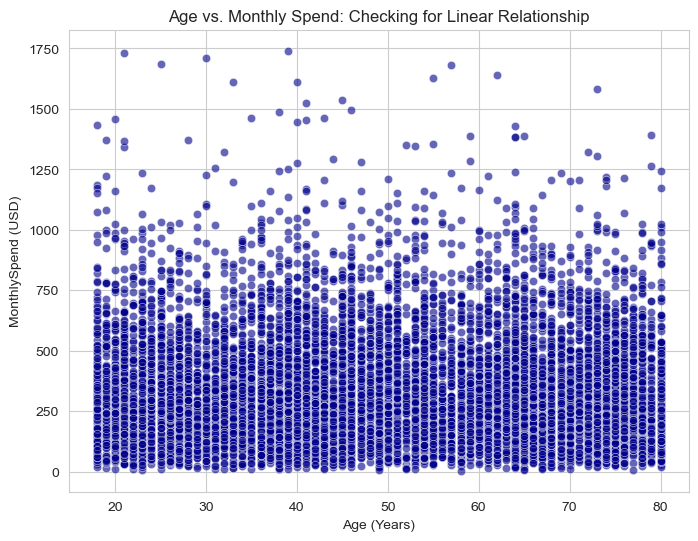

In [7]:
# Scatterplot: Age vs MonthlySpend
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Age', y='MonthlySpend', data=df, alpha=0.6, color='darkblue')
plt.title('Age vs. Monthly Spend: Checking for Linear Relationship')
plt.xlabel('Age (Years)')
plt.ylabel('MonthlySpend (USD)')
plt.show()


In [8]:
# Step 4: Bivariate Analysis
numeric_cols = ['Age', 'MonthlySpend', 'NumPets', 'DaysSinceLastInteraction']
correlation_matrix = df[numeric_cols].corr(method='pearson')

print("--- Pearson Correlation Matrix ---")
print(correlation_matrix.to_markdown(floatfmt=".4f"))

--- Pearson Correlation Matrix ---
|                          |     Age |   MonthlySpend |   NumPets |   DaysSinceLastInteraction |
|:-------------------------|--------:|---------------:|----------:|---------------------------:|
| Age                      |  1.0000 |        -0.0123 |   -0.0230 |                    -0.0040 |
| MonthlySpend             | -0.0123 |         1.0000 |    0.0206 |                     0.0061 |
| NumPets                  | -0.0230 |         0.0206 |    1.0000 |                    -0.0552 |
| DaysSinceLastInteraction | -0.0040 |         0.0061 |   -0.0552 |                     1.0000 |


In [9]:
# Average MonthlySpend by State, Education, and Gender
print("\n--- Average Monthly Spend by State (Top 5) ---")
spend_by_state = df.groupby('State')['MonthlySpend'].mean().sort_values(ascending=False).head(5)
print(spend_by_state.to_markdown(floatfmt=".2f"))

print("\n--- Average Monthly Spend by Education ---")
spend_by_education = df.groupby('Education')['MonthlySpend'].mean().sort_values(ascending=False)
print(spend_by_education.to_markdown(floatfmt=".2f"))

print("\n--- Average Monthly Spend by Gender ---")
spend_by_gender = df.groupby('Gender')['MonthlySpend'].mean().sort_values(ascending=False)
print(spend_by_gender.to_markdown(floatfmt=".2f"))


--- Average Monthly Spend by State (Top 5) ---
| State      |   MonthlySpend |
|:-----------|---------------:|
| Arizona    |         341.49 |
| Ohio       |         340.19 |
| California |         339.18 |
| Illinois   |         332.59 |
| New York   |         332.15 |

--- Average Monthly Spend by Education ---
| Education   |   MonthlySpend |
|:------------|---------------:|
| Master      |         334.25 |
| High School |         332.22 |
| Bachelor    |         331.88 |
| PhD         |         331.69 |
| Associate   |         327.88 |

--- Average Monthly Spend by Gender ---
| Gender     |   MonthlySpend |
|:-----------|---------------:|
| Male       |         333.17 |
| Female     |         331.36 |
| Non-Binary |         330.15 |


In [10]:
# Step 5 & 6: Formulate Hypotheses and Run Tests
# Test 1: Age and Spending

corr_age_spend, p_val_age_spend = stats.pearsonr(df['Age'], df['MonthlySpend'])
print("--- Test 1: Age vs MonthlySpend (Correlation) ---")
print(f"Pearson r: {corr_age_spend:.4f}, P-value: {p_val_age_spend:.4f}")

if p_val_age_spend < 0.05:
    print("Conclusion: Reject H0. There is a statistically significant linear correlation.")
else:
    print("Conclusion: Fail to Reject H0. There is NO statistically significant linear correlation.")

--- Test 1: Age vs MonthlySpend (Correlation) ---
Pearson r: -0.0123, P-value: 0.2030
Conclusion: Fail to Reject H0. There is NO statistically significant linear correlation.


In [11]:
# Test 2: Gender and Transaction Frequency
# Prepare data list for ANOVA
spend_by_gender = [df['MonthlySpend'][df['Gender'] == g] for g in df['Gender'].unique()]

# Perform Levene's test for assumption of equal variance
levene_gender = stats.levene(*spend_by_gender)
print("\n--- Test 2: Gender vs MonthlySpend (ANOVA) ---")
print(f"Levene's Test P-value (Variance): {levene_gender.pvalue:.4f}")

# Perform One-way ANOVA
f_val_gender, p_val_gender = stats.f_oneway(*spend_by_gender)
print(f"ANOVA F-statistic: {f_val_gender:.4f}, P-value: {p_val_gender:.4f}")

if p_val_gender < 0.05:
    print("Conclusion: Reject H0. Mean spend is statistically different by Gender.")
else:
    print("Conclusion: Fail to Reject H0. Mean spend is NOT statistically different by Gender.")



--- Test 2: Gender vs MonthlySpend (ANOVA) ---
Levene's Test P-value (Variance): 0.7111
ANOVA F-statistic: 0.1658, P-value: 0.8472
Conclusion: Fail to Reject H0. Mean spend is NOT statistically different by Gender.


In [12]:
# Test 3: Education and Average Monthly Spend

# Prepare data list for ANOVA
spend_by_education = [df['MonthlySpend'][df['Education'] == e] for e in df['Education'].unique()]

print("\n--- Test 3: Education vs MonthlySpend (ANOVA) ---")
# Perform One-way ANOVA
f_val_education, p_val_education = stats.f_oneway(*spend_by_education)
print(f"ANOVA F-statistic: {f_val_education:.4f}, P-value: {p_val_education:.4f}")

if p_val_education < 0.05:
    print("Conclusion: Reject H0. Mean spend is statistically different by Education.")
else:
    print("Conclusion: Fail to Reject H0. Mean spend is NOT statistically different by Education.")



--- Test 3: Education vs MonthlySpend (ANOVA) ---
ANOVA F-statistic: 0.2288, P-value: 0.9224
Conclusion: Fail to Reject H0. Mean spend is NOT statistically different by Education.


In [13]:
# Test 4: Age and Engagement

corr_age_days, p_val_age_days = stats.pearsonr(df['Age'], df['DaysSinceLastInteraction'])
print("\n--- Test 4: Age vs DaysSinceLastInteraction (Correlation) ---")
print(f"Pearson r: {corr_age_days:.4f}, P-value: {p_val_age_days:.4f}")

if p_val_age_days < 0.05:
    print("Conclusion: Reject H0. Age is significantly correlated with inactivity.")
else:
    print("Conclusion: Fail to Reject H0. Age is NOT significantly correlated with inactivity.")



--- Test 4: Age vs DaysSinceLastInteraction (Correlation) ---
Pearson r: -0.0040, P-value: 0.6817
Conclusion: Fail to Reject H0. Age is NOT significantly correlated with inactivity.


In [14]:
# Test 5: Marital Status and Pets

# Create Contingency Table
contingency_table = pd.crosstab(df['Married'], df['NumPets'])

# Perform Chi-square Test
chi2, p_val_chi2, dof, expected = stats.chi2_contingency(contingency_table)
print("\n--- Test 5: Married vs NumPets (Chi-square) ---")
print(f"Chi-square Statistic: {chi2:.4f}, P-value: {p_val_chi2:.4f}, Degrees of Freedom: {dof}")

if p_val_chi2 < 0.05:
    print("Conclusion: Reject H0. Marital status and pet ownership are DEPENDENT (related).")
else:
    print("Conclusion: Fail to Reject H0. Marital status and pet ownership are INDEPENDENT.")

# Show relationship breakdown for insight generation
print("\n--- Relationship Breakdown (Row Percentages) ---")
relationship_breakdown = pd.crosstab(df['Married'], df['NumPets'], margins=True, normalize='index') * 100
print(relationship_breakdown.to_markdown(floatfmt=".2f"))



--- Test 5: Married vs NumPets (Chi-square) ---
Chi-square Statistic: 177.6395, P-value: 0.0000, Degrees of Freedom: 4
Conclusion: Reject H0. Marital status and pet ownership are DEPENDENT (related).

--- Relationship Breakdown (Row Percentages) ---
| Married   |     0 |     1 |     2 |     3 |    4 |
|:----------|------:|------:|------:|------:|-----:|
| No        | 32.94 | 25.70 | 26.94 |  9.12 | 5.30 |
| Yes       | 23.66 | 34.76 | 24.39 | 11.74 | 5.44 |
| All       | 28.52 | 30.02 | 25.72 | 10.37 | 5.37 |


# Step 7: What This All Means for Your Business
Step 7: What This All Means for Your Business
Let me break down what we discovered and what you should actually do about it:

Finding #1: Demographics Don't Drive Spending
Here's the reality: whether your customers are male or female, college-educated or not, living in California or New York—it doesn't matter. The spending differences we saw earlier? They're just random noise. Statistically, these groups spend the same amount.
What you should do: Stop wasting money trying to target people based on gender, education, or location. These traditional demographic segments aren't worth your investment. Instead, look at how people behave—what they buy, when they last purchased, how much they've spent over time. That's where the real patterns are.

Finding #2: Age Doesn't Predict Engagement
We tested whether older customers are less engaged than younger ones. The answer? They're not. There's essentially zero correlation between age and how recently someone interacted with your brand (the correlation was -0.004, which is basically nothing).
What you should do: If you have any campaigns that assume "older = less engaged," kill them now. When you want to re-engage inactive customers, just look at who hasn't interacted recently—don't filter by age. A 65-year-old who bought something last month is way more valuable than a 25-year-old who hasn't been back in two years.

Finding #3: Marital Status + Pets = Real Segmentation Opportunity
Finally, some good news. We found a strong, statistically valid relationship between whether someone is married and whether they own pets:

Single/non-married customers are much more likely to have no pets (about 33% of them)
Married customers are significantly more likely to have at least one pet (about 35% have exactly one pet)

What you should do: Create actual lifestyle-based segments using this combination:

"Married + Pet Owner" segment → Target them with family-oriented products, pet supplies, bulk packages, home goods
"Single + No Pets" segment → Target them with travel deals, personal wellness products, experiences, convenience items

This isn't guesswork—this pattern is real and significant.

Finding #4: A Few Customers Are Driving Most of Your Revenue
The spending data is heavily skewed. Most customers spend a moderate amount, but a small group of high spenders is pulling your averages way up. These outliers are disproportionately valuable to your business.
What you should do (urgently): Identify your top 5% of customers by spending right now. Dig into their data:

What do they buy?
How often do they purchase?
What's their average order size?
Which product categories do they prefer?

Build a profile of these VIP customers, then create a dedicated retention strategy for them. Losing even a few of these customers would hurt your bottom line significantly. They deserve special treatment, personalized offers, and proactive account management.

Bottom Line
Stop segmenting by demographics that don't matter. Start focusing on behaviors, the marital status + pet ownership lifestyle pattern, and especially on identifying and protecting your highest-value customers. That's where your ROI will come from.RetryClaude can make mistakes. Please double-check responses.

